# Module 07 — The Honest-Scientist Workflow

*Tumor diagnosis, done rigorously — the ML equivalent of sterile technique.*

In the early 1990s, Dr. William Wolberg at the University of Wisconsin was diagnosing breast tumors from **fine-needle aspirates**: a thin needle draws a few cells from a breast mass, the cells are stained on a microscope slide, and a pathologist examines the nuclei. Malignant nuclei tend to be larger, lumpier, and more variable than benign ones. Wolberg's team digitized the slide images and, for each of 569 samples, computed 30 numbers describing the nuclei — mean radius, texture, concavity, and so on. Every sample's true diagnosis (malignant or benign) was confirmed, so the labels are trustworthy. The question they asked — and we'll ask — is: **can a computer diagnose the tumor from the numbers alone?**

This module is not about a new model. It's about **protocol** — the ML version of sterile technique, negative controls, and replicates. By the end, the accuracy we report will be a number we could defend in a lab meeting: measured with replicates, free of contamination, and touched-once.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# One fixed color per diagnosis, reused in every plot:
# benign = green (all clear), malignant = vermilion (alarm).
palette = sns.color_palette("colorblind")
DIAGNOSIS_COLORS = {"B": palette[2], "M": palette[3]}

## 1. Load the data — and fire the ID column

Same loading ritual as always. But this file has two booby traps we need to defuse before doing any science.

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (same as before)

# Download the Wisconsin breast-cancer dataset and convert it to a pandas table.
tumors = load_dataset("scikit-learn/breast-cancer-wisconsin", split="train")
df = tumors.to_pandas()

print("shape:", df.shape)   # (rows, columns)
df.head()

shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Two problems hiding in that table:

1. **`Unnamed: 32`** — scroll right: it's completely empty. The original file ended every line with a stray comma, so a phantom all-missing column appeared. We drop it.
2. **`id`** — the hospital's sample-tracking number. This one is dangerous, not just useless. **An ID must never be a feature.** IDs carry no biology, but they often *secretly correlate* with the label — e.g. if malignant samples were logged in batches, or one clinic (with one ID range) saw sicker patients. A model can "learn" from ID ranges and score well without learning anything about tumors — like a student who aces the exam by memorizing which answer sheet came from which pile. It would fail instantly on any new patient. Off it goes.

We'll also convert the diagnosis text into numbers, since models want numeric labels: **malignant = 1** (the thing we're trying to detect), **benign = 0**.

In [3]:
# drop() removes columns; columns=[...] lists which ones to remove.
df = df.drop(columns=["id", "Unnamed: 32"])

# .map() replaces each value in a column using a dictionary:
# every "M" becomes 1, every "B" becomes 0.
df["target"] = df["diagnosis"].map({"M": 1, "B": 0})

# X = the 30 measurement columns (the features).
# We drop the label columns so the model can't peek at the answer.
X = df.drop(columns=["diagnosis", "target"])
y = df["target"]                  # y = the labels (1 = malignant, 0 = benign)

print("X shape:", X.shape)        # should be 569 samples x 30 measurements
print("first five feature names:", list(X.columns[:5]))

X shape: (569, 30)
first five feature names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']


## 2. First look at the tumors

The first-look ritual from Module 02, plus one question that matters for every diagnosis problem: **how balanced are the classes?**

In [4]:
# How many of each diagnosis? value_counts() counts each distinct value.
print(df["diagnosis"].value_counts())
print()

# The 30 columns live on WILDLY different scales -- look at the means:
# .describe() gives summary stats; .loc picks just the rows we want.
print(X[["radius_mean", "area_mean", "smoothness_mean"]].describe().loc[["mean", "std"]])

diagnosis
B    357
M    212
Name: count, dtype: int64

      radius_mean   area_mean  smoothness_mean
mean    14.127292  654.889104         0.096360
std      3.524049  351.914129         0.014064


357 benign, 212 malignant — imbalanced, but not extreme. And look at those scales: `area_mean` averages ~655 while `smoothness_mean` averages ~0.096. Remember that gap — it becomes the whole plot of Section 5.

Now the biology. If pathologists diagnose by eye partly on nucleus size, the size measurements should separate the two groups:

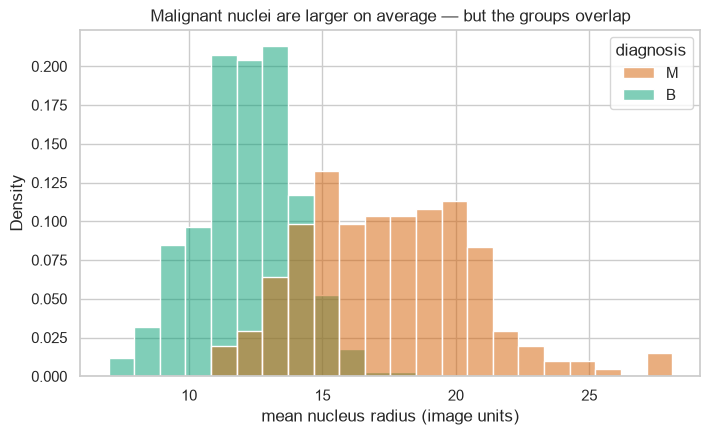

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# histplot draws overlapping histograms; hue="diagnosis" = one color per diagnosis.
# stat="density" rescales each group so their areas match (fair comparison
# even though there are more benign samples than malignant ones).
sns.histplot(data=df, x="radius_mean", hue="diagnosis",
             palette=DIAGNOSIS_COLORS, stat="density", common_norm=False, ax=ax)
ax.set_xlabel("mean nucleus radius (image units)")
ax.set_title("Malignant nuclei are larger on average — but the groups overlap")
plt.show()

Bigger nuclei → more likely malignant, exactly as the pathologists say. But the histograms overlap: no single measurement is a clean test. That's why we hand all 30 to a model — and why we need to *measure how good the model is* very carefully.

## 3. Shuffle luck: one split can mislead you

`train_test_split` shuffles the rows randomly before splitting, and `random_state` is just the seed for that shuffle. Change the seed → different patients end up in the test set → **a different accuracy for the exact same model**.

You would never report a qPCR result from a single well. Let's see why one train/test split is a single well.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier   # KNN (Module 04)

accuracies = []                   # we'll collect one accuracy per shuffle

for seed in range(10):            # range(10) gives seeds 0, 1, 2, ..., 9
    # stratify=y keeps the malignant/benign ratio the same in both halves,
    # like balancing treatment and control groups when assigning mice.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)

    model = KNeighborsClassifier()          # default k=5 neighbors
    model.fit(X_train, y_train)             # learn from the training portion
    acc = model.score(X_test, y_test)       # accuracy on the held-out portion
    accuracies.append(acc)

    # round(acc, 3) trims the number to 3 decimal places for printing.
    print("random_state =", seed, " ->  accuracy:", round(acc, 3))

random_state = 0  ->  accuracy: 0.923
random_state = 1  ->  accuracy: 0.923
random_state = 2  ->  accuracy: 0.937
random_state = 3  ->  accuracy: 0.923
random_state = 4  ->  accuracy: 0.888
random_state = 5  ->  accuracy: 0.909
random_state = 6  ->  accuracy: 0.937
random_state = 7  ->  accuracy: 0.937
random_state = 8  ->  accuracy: 0.944
random_state = 9  ->  accuracy: 0.93


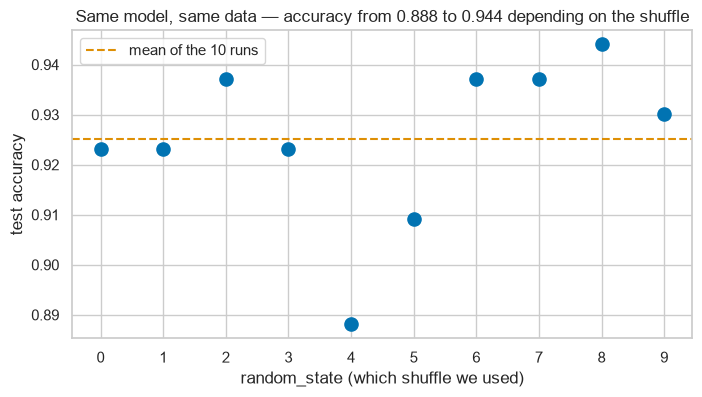

Which of these ten numbers would you publish?


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

# One dot per shuffle. zorder=3 just draws the dots on top of the grid lines.
ax.scatter(range(10), accuracies, s=90, color=palette[0], zorder=3)

# np.mean averages the list; axhline draws a horizontal reference line.
mean_acc = np.mean(accuracies)
ax.axhline(mean_acc, color=palette[1], linestyle="--",
           label="mean of the 10 runs")

ax.set_xticks(range(10))
ax.set_xlabel("random_state (which shuffle we used)")
ax.set_ylabel("test accuracy")
ax.set_title("Same model, same data — accuracy from " +
             str(round(min(accuracies), 3)) + " to " + str(round(max(accuracies), 3)) +
             " depending on the shuffle")
ax.legend()
plt.show()

print("Which of these ten numbers would you publish?")

A spread of about **5–6 percentage points** from shuffle luck alone. If you ran the split once, got lucky, and reported 94%, you'd be fooling yourself — and your readers.

## 4. Cross-validation: everyone takes a turn as the test set

The fix is the same as in the wet lab: **replicates**. **k-fold cross-validation** cuts the data into k equal chunks (*folds*), then runs k rounds: each round trains on k−1 folds and tests on the one held out, rotating so **every fold gets exactly one turn as the test set** (see the rotation diagram in the README). You get k scores and report the **mean and the spread**.

We use `StratifiedKFold`, the version that keeps the malignant/benign ratio the same in every fold — stratifying folds the same way we stratified the split above.

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5 folds; shuffle the rows once (seeded) before cutting the folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score does the whole rotation for us:
# it fits a FRESH copy of the model 5 times and returns the 5 test scores.
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)

print("the 5 fold scores:", scores.round(3))   # .round(3) rounds each number
print("mean accuracy:    ", round(scores.mean(), 3))
print("spread (std):     ", round(scores.std(), 3))

the 5 fold scores: [0.93  0.904 0.93  0.956 0.956]
mean accuracy:     0.935
spread (std):      0.02


Now we have an honest, replicated estimate: **~93.5% ± 2%** — one defensible number with error bars, instead of ten numbers to cherry-pick from.

## 5. Scaling: putting all 30 measurements on the same footing

KNN classifies by *distance*: it finds the k most similar tumors and lets them vote. But "similar" is computed across all 30 columns at once, and we saw that `area_mean` lives in the hundreds while `smoothness_mean` lives near 0.1. In the distance, area differences utterly drown out smoothness differences — like scoring cell similarity using diameter-in-nanometers plus pH, and pretending both counted. The model is effectively ignoring 29 of its 30 measurements.

**`StandardScaler`** fixes this: it re-expresses every column in units of "standard deviations away from that column's mean" (z-scores), so every measurement gets an equal voice.

The obvious way to use it: scale the whole table, then cross-validate. Watch the accuracy — and keep your sterile-technique instincts on alert, because we are about to make a mistake.

In [9]:
from sklearn.preprocessing import StandardScaler

# fit_transform does two things at once:
#   fit       = learn each column's mean and standard deviation
#   transform = convert every value to "standard deviations from the mean"
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X)     # scaled using ALL 569 samples

scores_scaled = cross_val_score(KNeighborsClassifier(), X_scaled_all, y, cv=cv)

print("unscaled KNN, mean CV accuracy:", round(scores.mean(), 3))
print("scaled KNN,   mean CV accuracy:", round(scores_scaled.mean(), 3))

# Error rate = 1 - accuracy. Compare how many mistakes each version makes:
print()
print("unscaled error rate:", round(1 - scores.mean(), 3))
print("scaled error rate:  ", round(1 - scores_scaled.mean(), 3))

unscaled KNN, mean CV accuracy: 0.935
scaled KNN,   mean CV accuracy: 0.967

unscaled error rate: 0.065
scaled error rate:   0.033


Scaling eliminated almost **half of the model's mistakes** (error ~6.5% → ~3.4%). Once every measurement gets an equal voice, KNN can actually use the texture and concavity information it was ignoring.

## 6. Data leakage: we just contaminated the experiment

But look again at what we did:

```python
X_scaled_all = scaler.fit_transform(X)     # <-- fitted on ALL 569 samples
```

The scaler **learned** each column's mean and spread **from the entire dataset** — including the samples that cross-validation was about to hold out as "unseen" test folds. Information from the test samples seeped into the preprocessing before the experiment even started.

This is **data leakage**: any time information from your test data influences any step that learns from data. And it is *exactly* contamination. The test set is your sealed, blinded sample — and we just pipetted a little of it into every tube on the bench. The result may look fine. It is still not a valid experiment.

The fix is a **`Pipeline`**: bundle the scaler and the model into a single object. When cross-validation runs, the pipeline re-fits the scaler **inside each training fold only**, and the held-out fold stays genuinely unseen — sterile technique built into the glassware, so this mistake becomes *impossible* to make.

In [10]:
from sklearn.pipeline import Pipeline

# A Pipeline is a list of named steps, run in order:
# step 1 "scaler": standardize the columns (fitted on training data only)
# step 2 "knn":    the classifier
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

scores_honest = cross_val_score(pipe, X, y, cv=cv)

print("LEAKY  (scale all, then CV):", round(scores_scaled.mean(), 4))
print("HONEST (scale inside CV):   ", round(scores_honest.mean(), 4))

LEAKY  (scale all, then CV): 0.9666
HONEST (scale inside CV):    0.9631


The two numbers differ by a fraction of a percent. So... why care?

Because **contaminated cultures don't always look contaminated** — that's precisely *why* sterile technique is a habit and not a judgment call. Here the leak happens to be nearly harmless (569 samples, and means/spreads are stable). On other datasets — small ones, or preprocessing steps that learn more than a mean, like feature selection — leakage inflates scores *dramatically*, and **you cannot know in advance which case you're in**. The leaky number is not "almost right"; it's *unverified*. The pipeline number is the one you can defend.

From here on, the pipeline **is** the model. One object, no leaks.

## 7. GridSearchCV: screening hyperparameter values honestly

KNN's `n_neighbors` (k) is a **hyperparameter** — a setting *we* choose rather than something the model learns. So far we've used the default k=5 on faith.

**`GridSearchCV`** runs the screen for us: give it a list of candidate values, and it evaluates *each one* with full cross-validation, then reports the winner. It's the honest version of "try stuff and keep the best" — every candidate is measured with replicates, under the same protocol.

In [11]:
from sklearn.model_selection import GridSearchCV

# The candidate values of k we want to screen:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

# The grid is a dictionary: which setting to vary, and the values to try.
# "knn__n_neighbors" means: the n_neighbors setting OF the pipeline step
# named "knn". (Two underscores connect the step name to the setting name.)
param_grid = {"knn__n_neighbors": k_values}

# For each candidate k: run 5-fold CV on the whole pipeline. 10 values x 5 folds
# = 50 model fits -- sklearn does them all with one .fit() call.
search = GridSearchCV(pipe, param_grid, cv=cv)
search.fit(X, y)

print("best setting found:      ", search.best_params_)
print("its mean CV accuracy:    ", round(search.best_score_, 4))
print()

# cv_results_ stores the full screen; let's print the mean score for every k.
mean_scores = search.cv_results_["mean_test_score"]
for i in range(len(k_values)):          # plain index loop over the candidates
    print("k =", k_values[i], "   mean CV accuracy:", round(mean_scores[i], 4))

best setting found:       {'knn__n_neighbors': 9}
its mean CV accuracy:     0.9666

k = 1    mean CV accuracy: 0.9508
k = 3    mean CV accuracy: 0.9666
k = 5    mean CV accuracy: 0.9631
k = 7    mean CV accuracy: 0.9649
k = 9    mean CV accuracy: 0.9666
k = 11    mean CV accuracy: 0.9631
k = 15    mean CV accuracy: 0.9596
k = 21    mean CV accuracy: 0.9526
k = 31    mean CV accuracy: 0.9526
k = 51    mean CV accuracy: 0.949


The screen says k≈3–9 all perform about equally well (~96.5%), with a slow decline for large k. A table is fine — but this deserves to be a *picture*.

## 8. The validation curve: underfitting and overfitting on one plot

A **validation curve** sweeps one hyperparameter across a range and plots **two** scores for each value:

- **training accuracy** — how well the model does on the very samples it learned from
- **cross-validation accuracy** — how well it does on held-out samples

Comparing the two curves is how you *see* underfitting and overfitting (the README has the annotated idealized version). For KNN, remember the direction: **small k = flexible** (k=1 memorizes every training tumor), **large k = rigid** (k=101 averages over a fifth of the dataset).

In [12]:
from sklearn.model_selection import validation_curve

# A wider sweep than the grid search, to expose both failure modes.
k_sweep = [1, 2, 3, 5, 7, 9, 15, 21, 31, 51, 101, 201]

# validation_curve returns TWO score tables, each with one row per k value
# and one column per fold (so 12 rows x 5 columns here).
train_scores, cv_scores = validation_curve(
    pipe, X, y,
    param_name="knn__n_neighbors",   # the setting to sweep (pipeline naming)
    param_range=k_sweep,             # the values to sweep over
    cv=cv)

# Average across the 5 folds. axis=1 means "average along each row".
train_mean = train_scores.mean(axis=1)
cv_mean = cv_scores.mean(axis=1)

print("k=1: training accuracy =", round(train_mean[0], 3),
      " but CV accuracy =", round(cv_mean[0], 3))

k=1: training accuracy = 1.0  but CV accuracy = 0.951


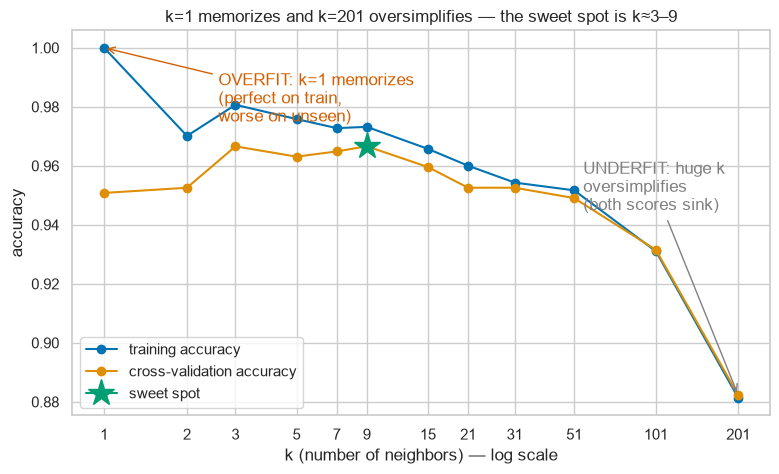

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_sweep, train_mean, marker="o", color=palette[0], label="training accuracy")
ax.plot(k_sweep, cv_mean, marker="o", color=palette[1], label="cross-validation accuracy")

# k spans 1 to 201, so a log-scaled axis spreads the small values out.
ax.set_xscale("log")
ax.set_xticks(k_sweep)
ax.set_xticklabels(k_sweep)      # show the actual k values as tick labels

# np.argmax returns the POSITION of the largest value in an array.
best_position = np.argmax(cv_mean)
ax.plot(k_sweep[best_position], cv_mean[best_position], marker="*",
        markersize=20, color=palette[2], zorder=5, label="sweet spot")

# Label the two failure zones on the plot itself.
ax.annotate("OVERFIT: k=1 memorizes\n(perfect on train,\nworse on unseen)",
            xy=(1, 1.0), xytext=(2.6, 0.975), color=palette[3],
            arrowprops=dict(arrowstyle="->", color=palette[3]))
ax.annotate("UNDERFIT: huge k\noversimplifies\n(both scores sink)",
            xy=(201, cv_mean[-1]), xytext=(55, 0.945), color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("k (number of neighbors) — log scale")
ax.set_ylabel("accuracy")
ax.set_title("k=1 memorizes and k=201 oversimplifies — the sweet spot is k≈3–9")
ax.legend(loc="lower left")
plt.show()

Read the story in the curves:

- **Left edge (k=1, overfit):** training accuracy is a perfect 100% — of course: each training tumor's nearest neighbor is *itself*. But CV accuracy is lower, and that **gap between the curves is memorization**, not learned biology.
- **Right edge (k=201, underfit):** with k this large, each vote averages over a third of the dataset. Both curves sink together — the model is too blunt to capture real structure.
- **Sweet spot:** the peak of the *orange* (cross-validation) curve. Always pick settings by the orange curve, never the blue one.

## 9. The final protocol: touch the test set once

One last subtlety. Our grid search tried ten values of k and we kept the *best* CV score. But a maximum-of-ten-tries is a slightly lucky number by construction — pick the best well out of ten and it's probably a bit above the true mean. So even `best_score_` is a touch optimistic.

The complete honest protocol closes this last loophole:

1. **Lock away a test set at the very start** — the sealed, blinded sample. It plays no part in tuning.
2. **Tune on the training portion only**: GridSearchCV, over a Pipeline, with cross-validation inside.
3. **Unseal the test set exactly once**, at the very end. That number is the one you report.

This is the workflow used in every serious ML paper — and it's just the blinded-validation-cohort design from clinical studies.

In [14]:
# --- STEP 1: lock away a test set FIRST (20% = 114 patients, untouched) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("training samples:", len(X_train), "   sealed test samples:", len(X_test))

# --- STEP 2: tune on the TRAINING portion only ---
# Same pipeline, same grid -- but .fit() only ever sees X_train.
final_search = GridSearchCV(pipe, param_grid, cv=5)
final_search.fit(X_train, y_train)

print("best k (chosen using training data only):",
      final_search.best_params_["knn__n_neighbors"])
print("tuning-time CV accuracy:", round(final_search.best_score_, 3))

# --- STEP 3: unseal the test set. ONCE. ---
# After the search, GridSearchCV automatically re-trained the winning
# pipeline on ALL the training data; .score() uses that final pipeline.
final_accuracy = final_search.score(X_test, y_test)

print()
print("FINAL honest test accuracy:", round(final_accuracy, 3))
print("(This is the number we report -- measured once, on 114 patients")
print(" that no fitted step of the workflow ever saw.)")

training samples: 455    sealed test samples: 114


best k (chosen using training data only): 7
tuning-time CV accuracy: 0.969

FINAL honest test accuracy: 0.956
(This is the number we report -- measured once, on 114 patients
 that no fitted step of the workflow ever saw.)


**~96% accuracy on truly unseen patients** — replicated during tuning, contamination-proof by construction, and evaluated exactly once. *That* is a number you can defend in lab meeting.

Notice it's a touch below the tuning-time CV score — that tiny gap is the selection optimism we predicted, now measured instead of hidden. If we'd kept re-running the test set until we liked the answer, we'd have quietly turned the test set into a second training set. Touch it once.

---

**The whole module in one sentence:** the test set is your sealed, blinded sample — anything that learns from data must learn from training data only, and you open the seal once, at the end.

Now try [exercises.md](exercises.md) — you'll run the sterile workflow on a different model and catch a leak on your own.